In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load required datasets
nav_history = pd.read_csv('../data/processed/nav_history_cleaned.csv')
fund_master = pd.read_csv('../data/processed/fund_master_cleaned.csv')
investor_transactions = pd.read_csv('../data/processed/investor_transactions_cleaned.csv')
scheme_performance = pd.read_csv('../data/processed/scheme_performance_cleaned.csv')
portfolio_holdings = pd.read_csv('../data/processed/portfolio_holdings_cleaned.csv')

In [77]:
print("\n=== Sample SIP Transactions ===")
print(
    investor_transactions[
        investor_transactions['transaction_type'] == 'SIP'
    ][['investor_id', 'transaction_date']]
    .head(20)
)
# Convert date columns
nav_history['date'] = pd.to_datetime(
    nav_history['date'],
    errors='coerce'
).dt.normalize()
investor_transactions['transaction_date'] = pd.to_datetime(
    investor_transactions['transaction_date'],
    format='%Y-%m-%d',
    errors='coerce'
)


=== Sample SIP Transactions ===
   investor_id transaction_date
0    INV003054       2024-01-01
2    INV003420       2024-01-01
3    INV003436       2024-01-01
5    INV001497       2024-01-01
6    INV000786       2024-01-01
7    INV000616       2024-01-01
8    INV003670       2024-01-01
9    INV002054       2024-01-01
11   INV001023       2024-01-01
12   INV002893       2024-01-01
13   INV000797       2024-01-01
15   INV000548       2024-01-01
16   INV000600       2024-01-01
17   INV004347       2024-01-01
18   INV000437       2024-01-01
19   INV000609       2024-01-01
20   INV000428       2024-01-01
23   INV004154       2024-01-01
24   INV000234       2024-01-01
27   INV001665       2024-01-01


In [78]:
# Historical VaR (95%) and CVaR
var_results = []
for amfi in nav_history['amfi_code'].unique():
    fund_nav = nav_history[nav_history['amfi_code'] == amfi].sort_values('date')
    if len(fund_nav) > 1:
        fund_nav['daily_return'] = fund_nav['nav'].pct_change()
        returns = fund_nav['daily_return'].dropna()
        if len(returns) > 0:
            var_95 = returns.quantile(0.05)
            cvar_95 = returns[returns <= var_95].mean()
            var_results.append({
                'amfi_code': amfi,
                'VaR_95': var_95,
                'CVaR_95': cvar_95
            })

fund_master['scheme_name_clean'] = (
    fund_master['scheme_name']
    .str.replace(' Fund - Regular Plan - Growth', ' (Regular)', regex=False)
    .str.replace(' Fund - Direct Plan - Growth', ' (Direct)', regex=False)
    .str.replace(' - Regular - Growth', ' (Regular)', regex=False)
    .str.replace(' - Direct - Growth', ' (Direct)', regex=False)
)

var_df = pd.DataFrame(var_results)
var_df = var_df.merge(fund_master[['amfi_code', 'scheme_name_clean']], on='amfi_code', how='left')
var_df = var_df[['amfi_code', 'scheme_name_clean', 'VaR_95', 'CVaR_95']]

# Export VaR/CVaR report
var_df.to_csv('../data/analytics/var_cvar_report.csv', index=False)

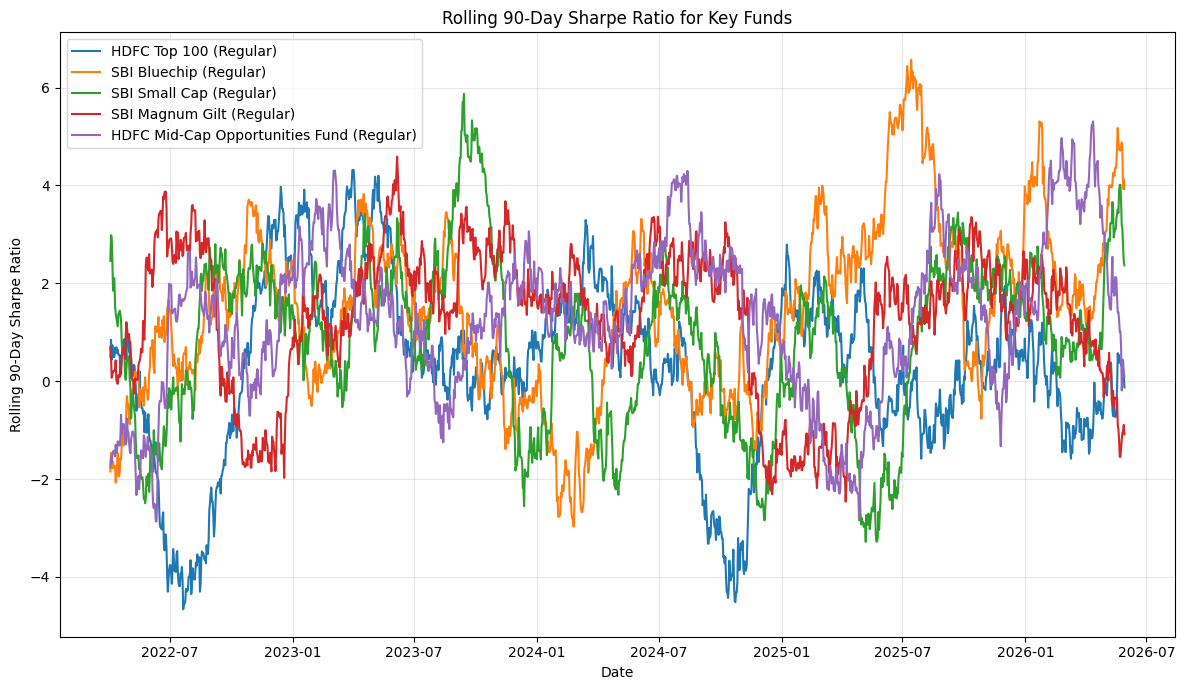

In [79]:
# Rolling 90-day Sharpe Ratio for 5 key funds

key_funds = [100016, 119551, 119598, 119120, 100033]

plt.figure(figsize=(12, 7))

for amfi in key_funds:
    fund_nav = (
        nav_history[nav_history['amfi_code'] == amfi]
        .sort_values('date')
        .copy()
    )

    fund_nav['daily_return'] = fund_nav['nav'].pct_change()

    fund_nav['rolling_sharpe'] = (
        fund_nav['daily_return'].rolling(window=90, min_periods=90).mean()
        / fund_nav['daily_return'].rolling(window=90, min_periods=90).std()
    ) * np.sqrt(252)

    # Remove NaN values before plotting
    plot_data = fund_nav.dropna(subset=['rolling_sharpe'])

    if len(plot_data) > 0:
        fund_name = fund_master[
            fund_master['amfi_code'] == amfi
        ]['scheme_name_clean'].iloc[0]

        plt.plot(
            plot_data['date'],
            plot_data['rolling_sharpe'],
            label=fund_name
        )

plt.xlabel('Date')
plt.ylabel('Rolling 90-Day Sharpe Ratio')
plt.title('Rolling 90-Day Sharpe Ratio for Key Funds')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    '../reports/figures/rolling_sharpe_chart.png',
    dpi=300,
    bbox_inches='tight'
)

#plt.close()

In [80]:
# Investor cohort analysis
investor_transactions = investor_transactions.dropna(subset=['transaction_date'])

investor_transactions['transaction_year'] = investor_transactions['transaction_date'].dt.year
first_transaction = investor_transactions.groupby('investor_id')['transaction_year'].min().reset_index()
first_transaction.columns = ['investor_id', 'first_year']

cohort_data = investor_transactions.merge(first_transaction, on='investor_id')
cohort_summary = []

for year in sorted(cohort_data['first_year'].unique()):
    if pd.isna(year):
        continue
    cohort = cohort_data[cohort_data['first_year'] == year]
    investors = cohort['investor_id'].unique()
    
    sip_trans = cohort[cohort['transaction_type'] == 'SIP']
    avg_sip = sip_trans['amount_inr'].mean() if len(sip_trans) > 0 else 0
    
    total_invested = cohort[cohort['transaction_type'] != 'Redemption']['amount_inr'].sum()
    
    top_fund = cohort[cohort['transaction_type'] != 'Redemption'].groupby('amfi_code')['amount_inr'].sum().idxmax() if len(cohort) > 0 else None
    top_fund_name = fund_master[fund_master['amfi_code'] == top_fund]['scheme_name_clean'].iloc[0] if top_fund else 'N/A'
    
    cohort_summary.append({
        'First_Year': int(year),
        'Num_Investors': len(investors),
        'Avg_SIP_Amount': avg_sip,
        'Total_Invested': total_invested,
        'Top_Fund': top_fund_name
    })

cohort_df = pd.DataFrame(cohort_summary)
cohort_df.to_csv('../data/analytics/cohort_analysis.csv', index=False)

print("\n=== Investor Cohort Summary ===")
print(cohort_df.to_string(index=False))


=== Investor Cohort Summary ===
 First_Year  Num_Investors  Avg_SIP_Amount  Total_Invested                      Top_Fund
       2024           4803    10996.885825      2258062304 Axis Small Cap Fund (Regular)
       2025            197    13505.209581        18992635    Axis Midcap Fund (Regular)


In [81]:
# SIP continuity analysis
sip_only = investor_transactions[investor_transactions['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])
sip_continuity = []

for investor in sip_only['investor_id'].unique():
    investor_sips = sip_only[sip_only['investor_id'] == investor].sort_values('transaction_date')
    if len(investor_sips) >= 6:
        valid_dates = investor_sips['transaction_date'].dropna()
        if len(valid_dates) >= 6:
            date_diff = valid_dates.diff().dropna().dt.days
            if len(date_diff) > 0:
                avg_gap = date_diff.mean()
                at_risk = avg_gap > 35
                sip_continuity.append({
                    'investor_id': investor,
                    'num_sips': len(investor_sips),
                    'avg_gap_days': avg_gap,
                    'at_risk': at_risk
                })

sip_df = pd.DataFrame(sip_continuity)
sip_df.to_csv('../data/analytics/sip_continuity.csv', index=False)

if len(sip_df) > 0:
    print("\n=== SIP Continuity Analysis (6+ SIPs) ===")
    print(sip_df.head())
    
    total_investors = len(sip_df)
    at_risk_investors = len(sip_df[sip_df['at_risk'] == True])
    continuity_rate = ((total_investors - at_risk_investors) / total_investors) * 100
    print(f"\nSIP Continuity Rate: {continuity_rate:.2f}%")
else:
    print("\nNo investors with 6+ valid SIP transactions found.")


=== SIP Continuity Analysis (6+ SIPs) ===
  investor_id  num_sips  avg_gap_days  at_risk
0   INV000004         6     85.400000     True
1   INV000008         6     70.400000     True
2   INV000010         6     64.800000     True
3   INV000011         7     40.166667     True
4   INV000012         8     57.000000     True

SIP Continuity Rate: 2.20%



=== Sector HHI Concentration (Equity Funds Only) ===
 amfi_code                            scheme_name_clean       HHI
    119092                 Axis Bluechip Fund (Regular) 2967.6909
    148569         Mirae Asset Tax Saver Fund (Regular) 2549.9194
    125498     HDFC Mid-Cap Opportunities Fund (Direct) 2531.5500
    102887                 UTI Flexi Cap Fund (Regular) 2513.8255
    149323                    DSP Midcap Fund (Regular) 2410.7664
    120505              ICICI Pru Midcap Fund (Regular) 2386.9504
    118635               Nippon India ETF Nifty 50 BeES 2374.9677
    119599                       SBI Small Cap (Direct) 2323.6120
    120506     ICICI Pru Value Discovery Fund (Regular) 2314.6434
    100033    HDFC Mid-Cap Opportunities Fund (Regular) 2276.4744
    119552                        SBI Bluechip (Direct) 2275.0835
    101207                ABSL Small Cap Fund (Regular) 2227.2651
    120504             ICICI Pru Bluechip Fund (Direct) 2212.1303
    118633         Nip

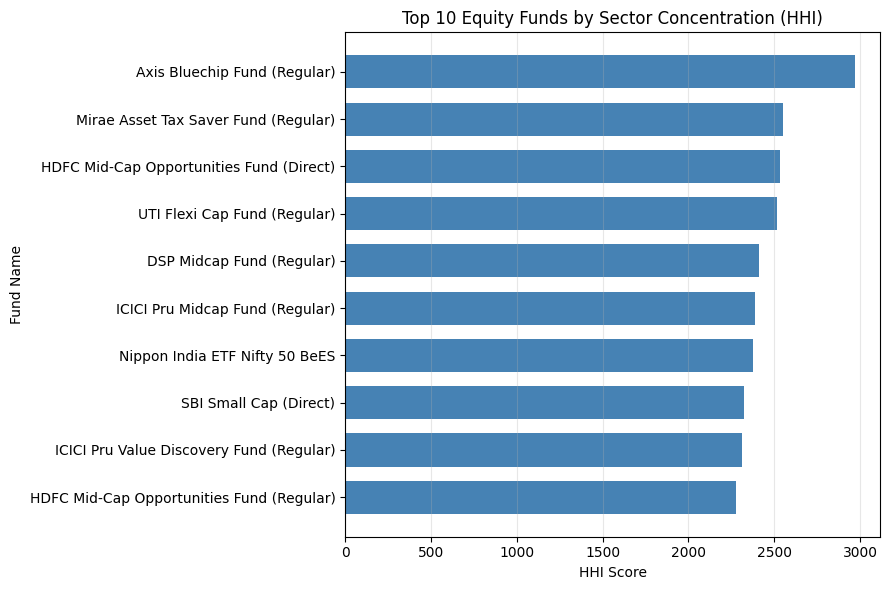

In [89]:
# Sector HHI concentration - Equity funds only
equity_funds = fund_master[fund_master['category'] == 'Equity']['amfi_code'].unique()
equity_holdings = portfolio_holdings[portfolio_holdings['amfi_code'].isin(equity_funds)]

hhi_results = []
for amfi in equity_holdings['amfi_code'].unique():
    fund_holdings = equity_holdings[equity_holdings['amfi_code'] == amfi]
    sector_weights = fund_holdings.groupby('sector')['weight_pct'].sum().reset_index()
    sector_weights['weight_decimal'] = sector_weights['weight_pct'] / 100
    sector_weights['weight_squared'] = sector_weights['weight_decimal'] ** 2
    hhi = sector_weights['weight_squared'].sum() * 10000
    
    hhi_results.append({
        'amfi_code': amfi,
        'HHI': hhi
    })

hhi_df = pd.DataFrame(hhi_results)
hhi_df = hhi_df.sort_values('HHI', ascending=False)

hhi_df = hhi_df.merge(
    fund_master[['amfi_code', 'scheme_name_clean']],
    on='amfi_code',
    how='left'
)

hhi_df = hhi_df[['amfi_code', 'scheme_name_clean', 'HHI']]
hhi_df.to_csv('../data/analytics/sector_hhi.csv', index=False)

print("\n=== Sector HHI Concentration (Equity Funds Only) ===")
print(hhi_df.to_string(index=False))
print(f"\nHighest Concentration Fund: {hhi_df.iloc[0]['scheme_name_clean']} (HHI: {hhi_df.iloc[0]['HHI']:.2f})")

# HHI comparison chart
plt.figure(figsize=(9, 6))
top_10_hhi = hhi_df.head(10)
bars = plt.barh(top_10_hhi['scheme_name_clean'], top_10_hhi['HHI'], height=0.7, color='steelblue')
plt.xlabel('HHI Score')
plt.ylabel('Fund Name')
plt.title('Top 10 Equity Funds by Sector Concentration (HHI)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../reports/figures/hhi_comparison_chart.png', dpi=300, bbox_inches='tight')
#plt.close()

In [83]:
# Advanced analysis

# Highest VaR/CVaR risk
highest_var = var_df.loc[var_df['VaR_95'].idxmin()]

# Largest investor cohort
if len(cohort_df) > 0:
    max_investors = cohort_df.loc[cohort_df['Num_Investors'].idxmax()]
    max_investment = cohort_df.loc[cohort_df['Total_Invested'].idxmax()]

# SIP continuity
if len(sip_df) > 0:
    at_risk_pct = (sip_df['at_risk'].sum() / len(sip_df)) * 100

# Highest HHI concentration
highest_hhi = hhi_df.iloc[0]

print(f"Highest VaR Risk: {highest_var['scheme_name_clean']} ({highest_var['VaR_95']:.4f})")
print(f"Highest CVaR Risk: {highest_var['scheme_name_clean']} ({highest_var['CVaR_95']:.4f})")
if len(cohort_df) > 0:
    print(f"Largest Investor Cohort: {int(max_investors['First_Year'])} "
          f"({max_investors['Num_Investors']} investors)")
    print(f"Highest Investment Cohort: {int(max_investment['First_Year'])} "
          f"(₹{max_investment['Total_Invested']:,.0f})")
else:
    print("Investor Cohort: No valid data available.")
if len(sip_df) > 0:
    print(f"SIP At-Risk Investors: {at_risk_pct:.1f}%")
else:
    print("SIP Continuity: No investors with 6+ valid SIP transactions.")
print(f"Highest Sector HHI: {highest_hhi['scheme_name_clean']} "
      f"({highest_hhi['HHI']:.2f})")

Highest VaR Risk: ABSL Small Cap Fund (Regular) (-0.0239)
Highest CVaR Risk: ABSL Small Cap Fund (Regular) (-0.0303)
Largest Investor Cohort: 2024 (4803 investors)
Highest Investment Cohort: 2024 (₹2,258,062,304)
SIP At-Risk Investors: 97.8%
Highest Sector HHI: Axis Bluechip Fund (Regular) (2967.69)


## Advanced Analytics Summary

1. **Highest VaR Risk:** ABSL Small Cap Fund (Regular) recorded the highest Value at Risk (VaR) at **-2.39%**, indicating the highest estimated potential daily loss among the analysed funds.

2. **Highest CVaR Risk:** ABSL Small Cap Fund (Regular) also recorded the highest Conditional VaR (CVaR) at **-3.03%**, indicating greater potential losses under adverse market conditions.

3. **Largest Investor Cohort:** The **2024 investor cohort** was the largest, with **4,803 investors** based on their first recorded transaction year.

4. **Highest Investment Cohort:** The **2024 cohort** also recorded the highest total investment amount at approximately **₹225.81 crore**.

5. **SIP Continuity Risk:** **97.8%** of investors with 6+ SIP transactions were classified as at-risk based on an average SIP gap exceeding 35 days, indicating potential SIP retention concerns.

6. **Portfolio Concentration:** Axis Bluechip Fund (Regular) recorded the highest sector concentration HHI at **2,967.69**, indicating relatively high portfolio concentration.